In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

# **`Load Dataset`**

In [18]:
df = pd.read_csv('/content/bmw.csv')

In [19]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


**Exploratory Data Analysis (EDA):** It involves visualizing and analyzing datasets to make informed preprocessing and feature selection decisions.

# `Exploratory Data Analysis (EDA)`

**Dataset Info**

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  object 
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  object 
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  object 
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 758.2+ KB


**Missing Values**

In [21]:
df.isnull().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


**Price Distribution**

Text(0.5, 1.0, 'BMW Price Distribution')

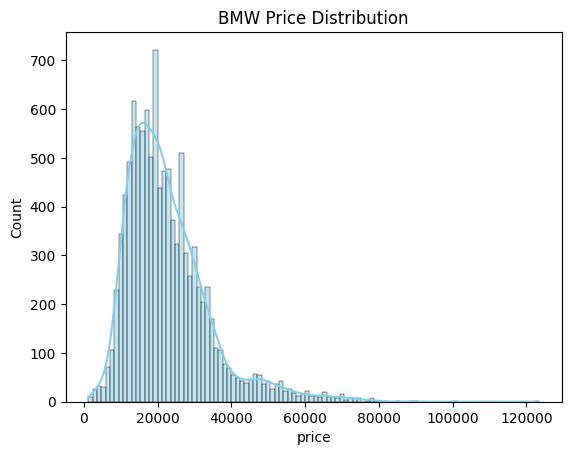

In [22]:
sns.histplot(df['price'], kde=True, color='skyblue')
plt.title("BMW Price Distribution")


 **Mileage vs Price**

Text(0.5, 1.0, 'Mileage VS Price')

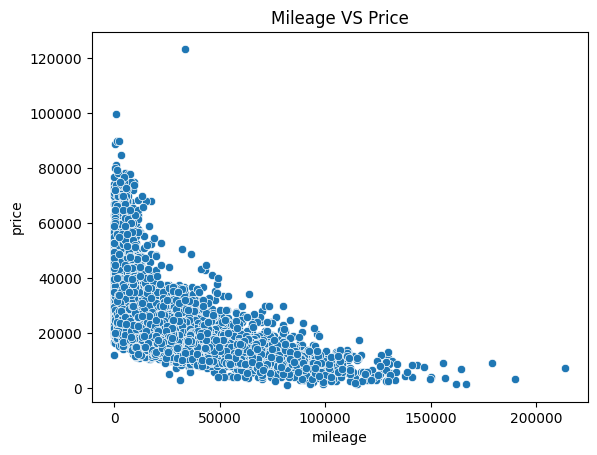

In [23]:
sns.scatterplot(x='mileage', y='price' , data=df)
plt.title('Mileage VS Price')

**Average Price by Model**

Text(0, 0.5, 'Average Price (£)')

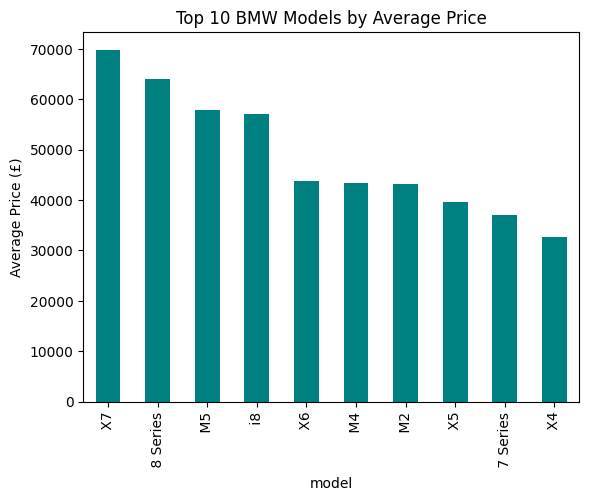

In [24]:
avg_price = df.groupby('model')['price'].mean().sort_values(ascending=False).head(10)
avg_price.plot(kind='bar', color='teal')
plt.title("Top 10 BMW Models by Average Price")
plt.ylabel("Average Price (£)")

**Correlation Heatmap**

Text(0.5, 1.0, 'Feature Correlation')

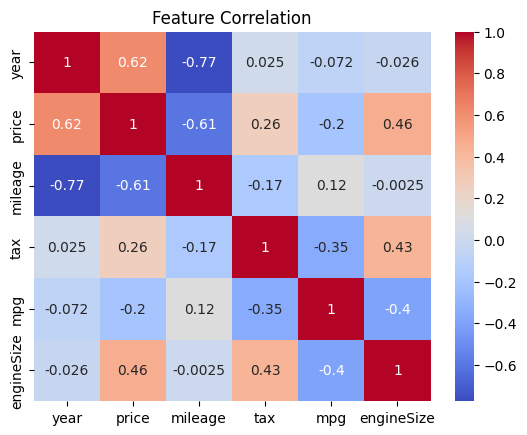

In [25]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")

# `Data Preprocessing`

**Drop duplicates and missing values**

In [26]:
df.drop_duplicates(inplace=True)

In [27]:
df.dropna(inplace=True)

**Encode categorical features**

In [28]:
label_encoder = LabelEncoder()
for col in ['model', 'transmission', 'fuelType']:
    df[col] = label_encoder.fit_transform(df[col])

**Features and target**

In [29]:
X = df[['model', 'year', 'mileage', 'tax', 'engineSize', 'mpg', 'transmission', 'fuelType']]
y = df['price']

**Split data**

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Feature scaling**

In [31]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# `Model Training`


**Linear Regression**


In [32]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lr = lin_reg.predict(X_test)

**Random Forest Regressor**

In [33]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# `Model Evaluation`

In [36]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n📈 {model_name} Evaluation:")
    print("R² Score:", round(r2_score(y_test, y_pred), 3))
    print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))

# Now call it separately for both models
evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest Regressor")



📈 Linear Regression Evaluation:
R² Score: 0.746
MAE: 3853.92
RMSE: 5622.04

📈 Random Forest Regressor Evaluation:
R² Score: 0.947
MAE: 1551.9
RMSE: 2559.87


# `Visualization of Predictions`

Text(0.5, 1.0, 'Actual vs Predicted Prices (Random Forest)')

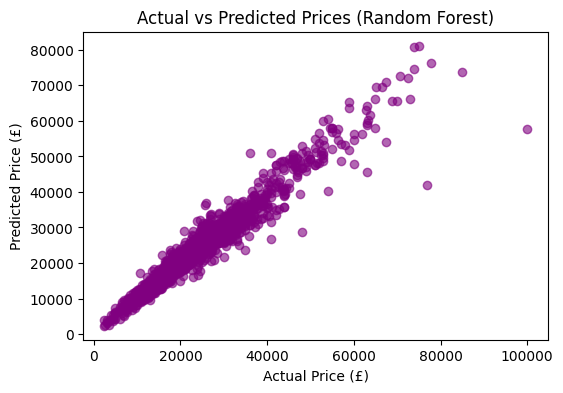

In [37]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='purple')
plt.xlabel("Actual Price (£)")
plt.ylabel("Predicted Price (£)")
plt.title("Actual vs Predicted Prices (Random Forest)")

# `Save the Model`

In [38]:
joblib.dump(rf, "bmw_price_model.pkl")
print("✅ Model Saved as 'bmw_price_model.pkl'")

print("\n🚀 Project Completed Successfully!")

✅ Model Saved as 'bmw_price_model.pkl'

🚀 Project Completed Successfully!
